# Notebook 1 — Data Exploration & Preparation
## Kaggle Bike Sharing Demand

**Objective:** Load the raw Kaggle Bike Sharing Demand dataset, perform exploratory data analysis (EDA), engineer time-based features, preprocess the data, and save a clean version for model training.

**Dataset columns**

| Column | Description |
|--------|-------------|
| `datetime` | Hourly date + timestamp |
| `season` | 1=Spring, 2=Summer, 3=Fall, 4=Winter |
| `holiday` | Whether the day is a public holiday |
| `workingday` | Neither a weekend nor holiday |
| `weather` | 1=Clear → 4=Heavy Rain/Snow |
| `temp` | Temperature in °C |
| `atemp` | Feels-like temperature in °C |
| `humidity` | Relative humidity |
| `windspeed` | Wind speed |
| `casual` | Non-registered user rentals |
| `registered` | Registered user rentals |
| `count` | **Target** — total rentals |

In [3]:
# Install any missing dependencies into the active notebook kernel.
# This is safe to re-run — pip skips packages that are already installed.
%pip install -q numpy pandas matplotlib seaborn scipy scikit-learn xgboost joblib fastapi

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── project root on sys.path ──────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_DIR, PROCESSED_DIR, ARTIFACTS_DIR, BRONZE_DIR

# Ensure directories exist
for d in (RAW_DIR, PROCESSED_DIR, ARTIFACTS_DIR, BRONZE_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)

Project root: /Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final
Raw data dir: /Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/data/raw


## 1. Load Raw Data

Download from Kaggle (requires `~/.kaggle/kaggle.json`) or place `train.csv` manually in `data/raw/`.

In [5]:
# ── Try Kaggle download; fall back to existing file ───────────────────────────
RAW_TRAIN = RAW_DIR / "train.csv"

if not RAW_TRAIN.exists():
    try:
        from src.data.ingest import download_competition
        download_competition("bike-sharing-demand", RAW_DIR, force=False)
        print("Downloaded from Kaggle.")
    except Exception as e:
        print(f"Kaggle download failed ({e}). Place train.csv in {RAW_DIR} manually.")
else:
    print(f"Using existing file: {RAW_TRAIN}")

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_TRAIN, parse_dates=["datetime"])
print(f"\nShape: {df.shape}")
print(f"Date range: {df['datetime'].min()}  →  {df['datetime'].max()}")
df.head()

Using existing file: /Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/data/raw/train.csv

Shape: (10886, 12)
Date range: 2011-01-01 00:00:00  →  2012-12-19 23:00:00


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 2. Initial Data Exploration

In [6]:
# Data types and nulls
print("=== dtypes ===")
print(df.dtypes)
print("\n=== Missing values ===")
print(df.isnull().sum())
print(f"\nDuplicated rows: {df.duplicated().sum()}")

=== dtypes ===
datetime      datetime64[ns]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

=== Missing values ===
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Duplicated rows: 0


In [7]:
# Descriptive statistics
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
datetime,10886,2011-12-27 05:56:22.399411968,2011-01-01 00:00:00,2011-07-02 07:15:00,2012-01-01 20:30:00,2012-07-01 12:45:00,2012-12-19 23:00:00,NaN
season,10886.0,2.506614,1.0,2.0,3.0,4.0,4.0,1.116174
holiday,10886.0,0.028569,0.0,0.0,0.0,0.0,1.0,0.166599
workingday,10886.0,0.680875,0.0,0.0,1.0,1.0,1.0,0.466159
weather,10886.0,1.418427,1.0,1.0,1.0,2.0,4.0,0.633839
temp,10886.0,20.23086,0.82,13.94,20.5,26.24,41.0,7.79159
atemp,10886.0,23.655084,0.76,16.665,24.24,31.06,45.455,8.474601
humidity,10886.0,61.88646,0.0,47.0,62.0,77.0,100.0,19.245033
windspeed,10886.0,12.799395,0.0,7.0015,12.998,16.9979,56.9969,8.164537
casual,10886.0,36.021955,0.0,4.0,17.0,49.0,367.0,49.960477


## 3. Target Variable Analysis (`count`)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Distribution of Bike Rentals (count)", fontsize=13, fontweight="bold")

# Raw distribution
axes[0].hist(df["count"], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set(title="Raw count", xlabel="count", ylabel="Frequency")

# Log-transformed
axes[1].hist(np.log1p(df["count"]), bins=50, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].set(title="log1p(count)  ←  model target", xlabel="log1p(count)", ylabel="Frequency")

plt.tight_layout()
plt.show()

print(f"Skewness (raw):      {df['count'].skew():.3f}")
print(f"Skewness (log1p):    {np.log1p(df['count']).skew():.3f}")

## 4. Time-based Analysis

Extract time components and explore how rentals vary by hour, day-of-week, month, and season.

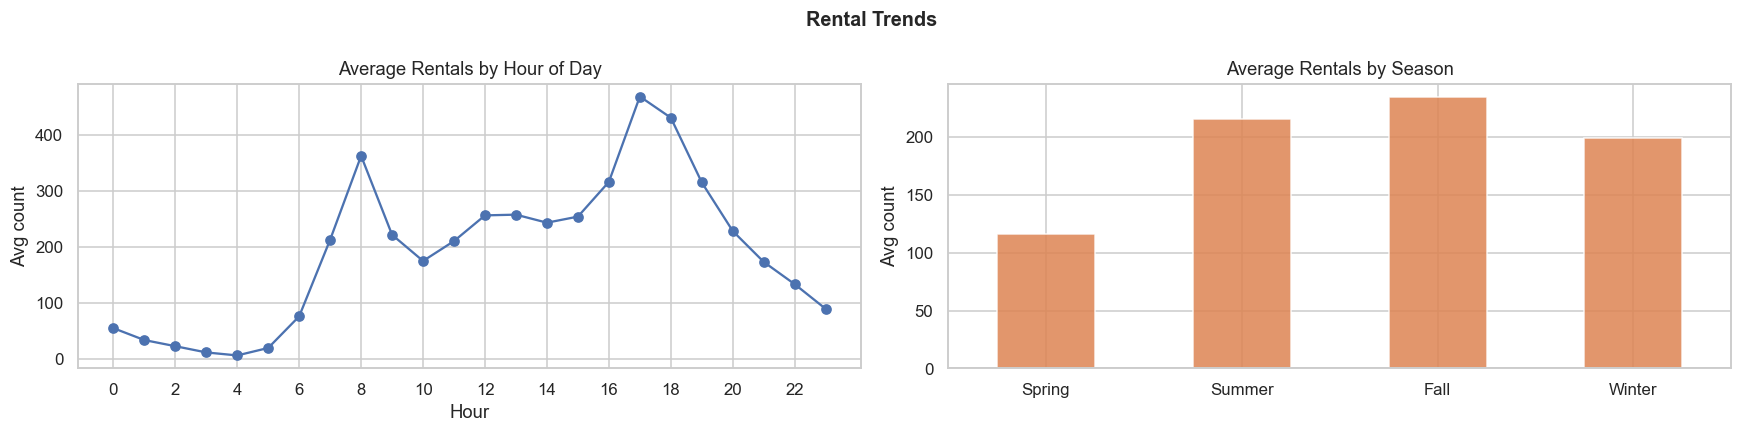

In [8]:
# Add time features for EDA
df["year"]      = df["datetime"].dt.year
df["month"]     = df["datetime"].dt.month
df["day"]       = df["datetime"].dt.day
df["hour"]      = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek   # 0=Mon … 6=Sun
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# ── Hourly & seasonal trends ──────────────────────────────────────────────────
season_map   = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
df["season_label"] = df["season"].map(season_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Rental Trends", fontsize=13, fontweight="bold")

# Hourly average
hourly = df.groupby("hour")["count"].mean()
axes[0].plot(hourly.index, hourly.values, marker="o", color="#4C72B0")
axes[0].set(title="Average Rentals by Hour of Day", xlabel="Hour", ylabel="Avg count")
axes[0].set_xticks(range(0, 24, 2))

# Seasonal average
seasonal = df.groupby("season_label")["count"].mean().reindex(["Spring","Summer","Fall","Winter"])
seasonal.plot.bar(ax=axes[1], color="#DD8452", alpha=0.85, edgecolor="white")
axes[1].set(title="Average Rentals by Season", xlabel="", ylabel="Avg count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

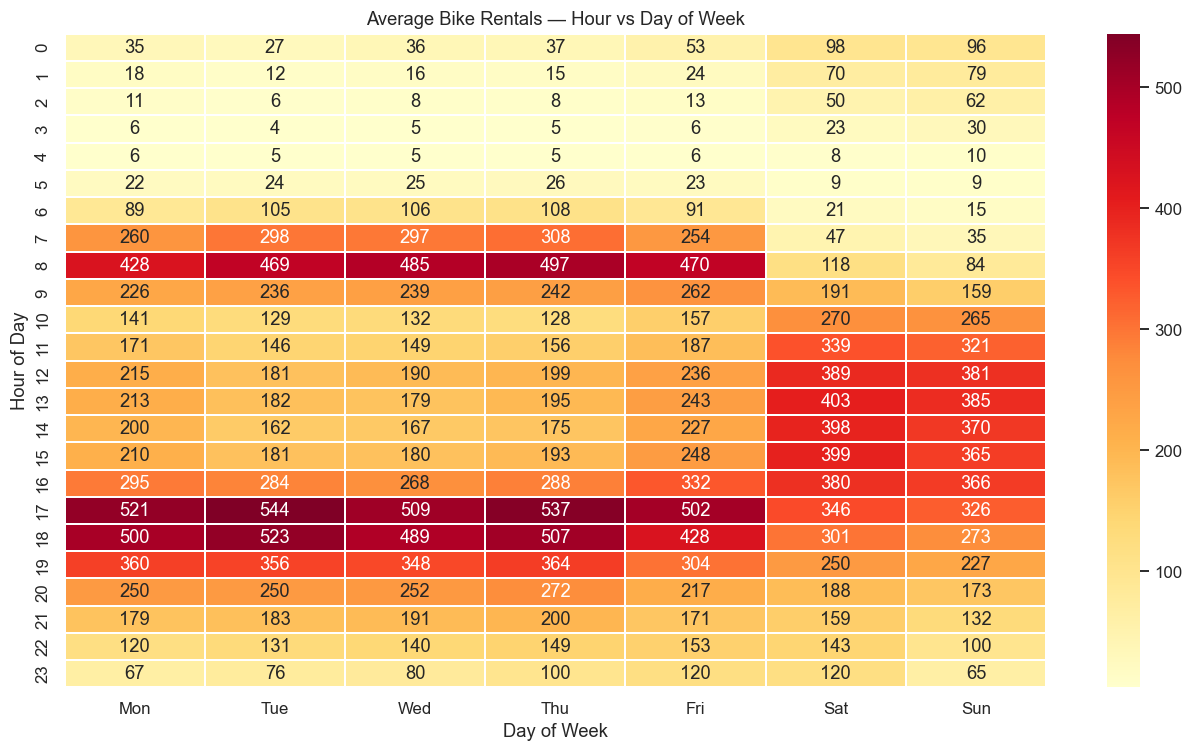

In [9]:
# Hour × day-of-week heatmap
pivot = df.pivot_table(values="count", index="hour", columns="dayofweek", aggfunc="mean")
pivot.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.3, ax=ax)
ax.set(title="Average Bike Rentals — Hour vs Day of Week", xlabel="Day of Week", ylabel="Hour of Day")
plt.tight_layout()
plt.show()

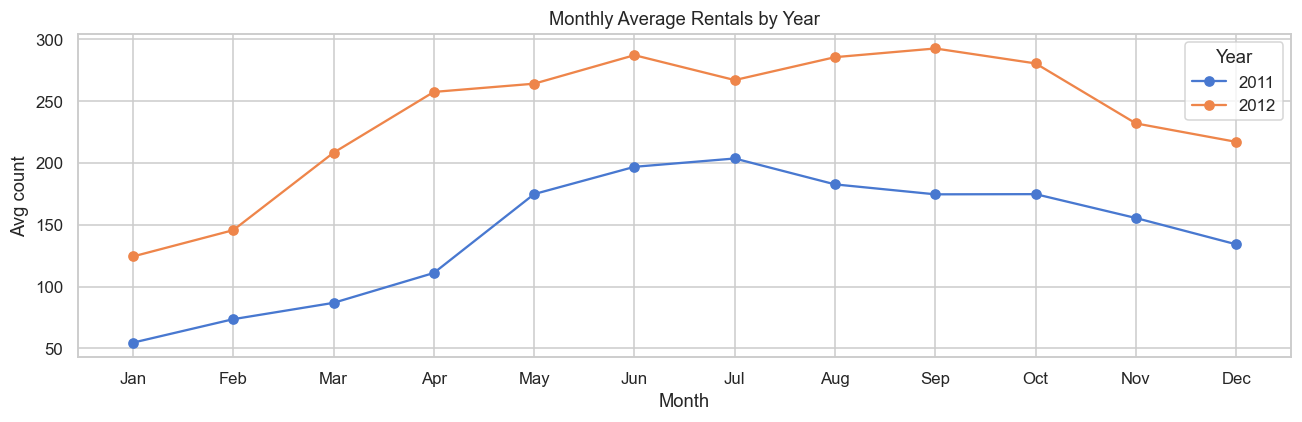

In [10]:
# Monthly trend (year comparison)
monthly = df.groupby(["year", "month"])["count"].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 4))
for yr, grp in monthly.groupby("year"):
    ax.plot(grp["month"], grp["count"], marker="o", label=str(yr))
ax.set(title="Monthly Average Rentals by Year", xlabel="Month", ylabel="Avg count")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend(title="Year")
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

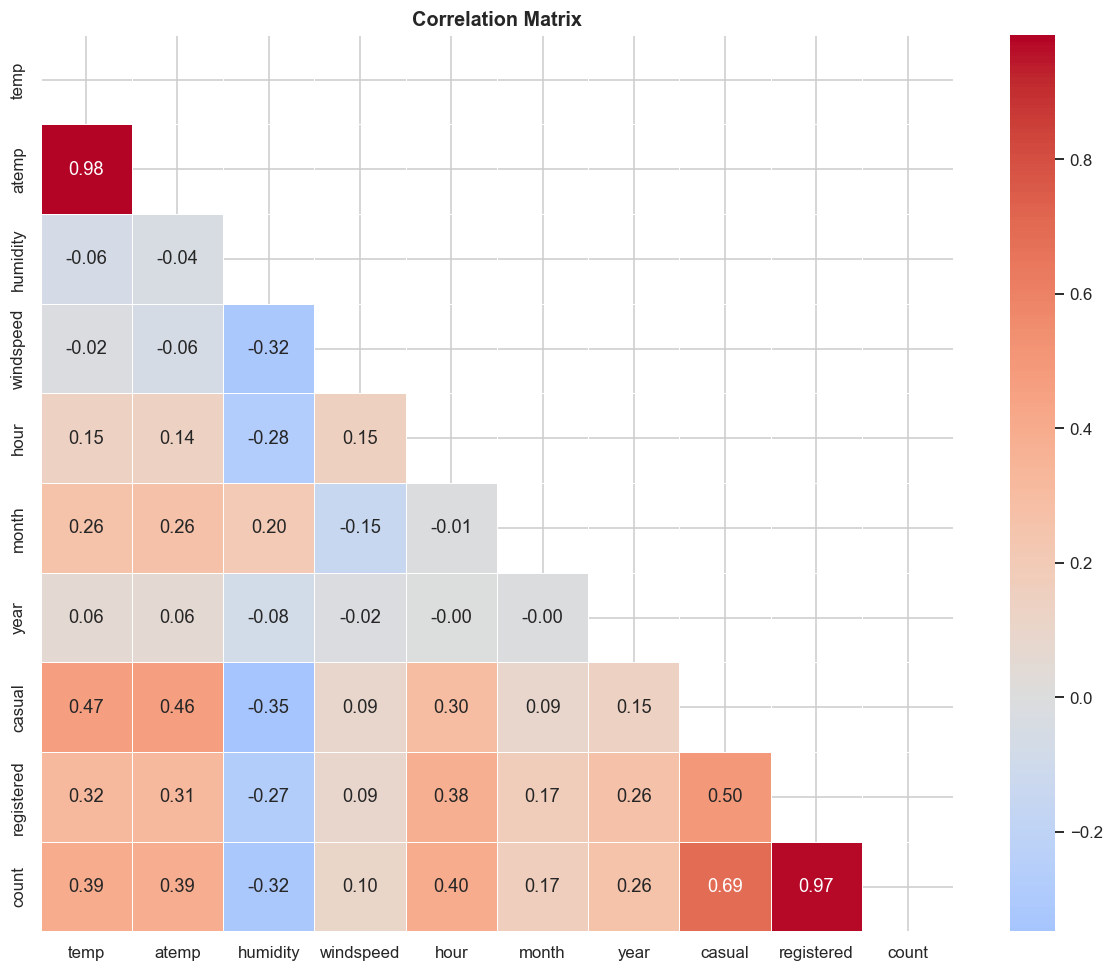

In [11]:
num_cols = ["temp", "atemp", "humidity", "windspeed", "hour",
            "month", "year", "casual", "registered", "count"]
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax)
ax.set_title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

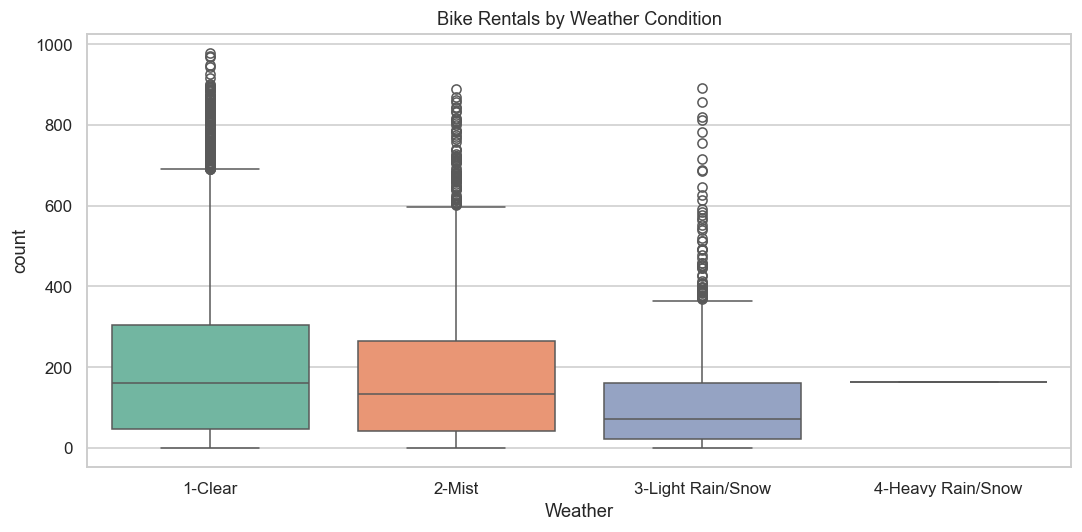

In [12]:
# Weather vs count boxplot
weather_map = {1: "1-Clear", 2: "2-Mist", 3: "3-Light Rain/Snow", 4: "4-Heavy Rain/Snow"}
df["weather_label"] = df["weather"].map(weather_map)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="weather_label", y="count",
            order=sorted(df["weather_label"].unique()),
            palette="Set2", ax=ax)
ax.set(title="Bike Rentals by Weather Condition", xlabel="Weather", ylabel="count")
plt.tight_layout()
plt.show()

## 6. Feature Engineering & Preprocessing

- Drop leakage columns (`casual`, `registered`)  
- Apply `src.preprocess` to generate the cleaned CSV and versioning artifacts (`dataset_meta.json`, `data_profile.json`, `feature_config.json`)

In [15]:
from src.data.preprocess import preprocess

PROCESSED_PATH = PROCESSED_DIR / "train_processed.csv"
preprocess(RAW_TRAIN, PROCESSED_PATH)

# Verify
df_proc = pd.read_csv(PROCESSED_PATH, parse_dates=["datetime"])
print(f"Processed dataset: {df_proc.shape}")
print(f"Columns: {list(df_proc.columns)}")
df_proc.head()

Processed dataset: (10886, 13)
Columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'count', 'year', 'month', 'hour', 'dayofweek']


,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,count,year,month,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,16,2011,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,40,2011,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,32,2011,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,75,0.0,13,2011,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,75,0.0,1,2011,1,4,5


In [16]:
# Show generated versioning artifacts
import json
for fname in ("dataset_meta.json", "data_profile.json", "feature_config.json"):
    p = ARTIFACTS_DIR / fname
    if p.exists():
        print(f"\n=== {fname} ===")
        data = json.loads(p.read_text())
        if fname == "data_profile.json":
            # Show first 3 columns only
            preview = {k: v for k, v in list(data.items())[:3]}
            print(json.dumps(preview, indent=2))
        else:
            print(json.dumps(data, indent=2))


=== dataset_meta.json ===
{
  "source": "kaggle/bike-sharing-demand",
  "generated_at": "2026-05-10T12:14:15.338581Z",
  "raw_path": "/Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/data/raw/train.csv",
  "raw_sha256": "0cf70c35eeb6405a40cc9e124854e2da901fa88fe7374a75d141e7401bf4c857",
  "raw_rows": 10886,
  "raw_columns": [
    "datetime",
    "season",
    "holiday",
    "workingday",
    "weather",
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "casual",
    "registered",
    "count"
  ],
  "processed_path": "/Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/data/processed/train_processed.csv",
  "processed_sha256": "582aa3a4e8de1d3f1ba379ba78e31410069d9983b138e60d31fe8ddae26b7fc9",
  "processed_rows": 10886,
  "processed_columns": [
    "datetime",
    "season",
    "holiday",
    "workingday",
    "weather",
    "temp",
    "humidity",
    "windspeed",
    "count",
    "year",
    "month",
    "hour",
    "dayofweek"
  ]
}

=== data_profile.json ===
{
  "generated_

## 7. Summary

| Step | Output |
|------|--------|
| Raw data loaded | `data/raw/train.csv` |
| Missing values | None |
| Target distribution | Right-skewed → use `log1p(count)` as model target |
| Key time patterns | Morning (8am) and evening (5-6pm) peaks on weekdays |
| Top correlated features | `temp`, `hour`, `year` |
| Processed data saved | `data/processed/train_processed.csv` |
| Versioning artifacts | `dataset_meta.json`, `data_profile.json`, `feature_config.json` |

> **Next:** Open `02_model_training_and_evaluation.ipynb`